In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [44]:
no2 = pd.read_csv("low RSD ready data/no2_bysite.csv")
o3 = pd.read_csv("low RSD ready data/o3_bysite.csv")

## Little bit of EDA to figure out how to split data to ensure lower values are represented

In [45]:
thresholds = {
    "dpw": 15.6,
    "pema": 14.8,
    "pha": 15.0
}

for site, threshold in thresholds.items():
    below = (no2[site] < threshold).sum()
    above = (no2[site] >= threshold).sum()
    total = below + above

    print(f"\n{site.upper()}")
    print(f"Below {threshold} ppb: {below} ({below/total:.1%})")
    print(f"Above/equal {threshold} ppb: {above} ({above/total:.1%})")
    print(f"Total: {total}")


DPW
Below 15.6 ppb: 975 (17.4%)
Above/equal 15.6 ppb: 4638 (82.6%)
Total: 5613

PEMA
Below 14.8 ppb: 1855 (35.7%)
Above/equal 14.8 ppb: 3347 (64.3%)
Total: 5202

PHA
Below 15.0 ppb: 1471 (26.2%)
Above/equal 15.0 ppb: 4145 (73.8%)
Total: 5616


## For the following approaches to identifying ideal calibration time periods, we ignore the DEM data

### In this first approach, we exclude the MJF Quant from low RSD time period identification

In [46]:
no2_rsd = no2.dropna(subset=["dpw", "pema", "pha"]).copy()

cols = ["dpw", "pema", "pha"]

#calculate mean and standard deviation
row_mean = no2_rsd[cols].mean(axis=1)
row_std = no2_rsd[cols].std(axis=1, ddof=1)

no2_rsd["rsd"] = 100 * row_std / row_mean

no2_rsd.head()

,datetime_utc,dem,dpw,mjf,pema,pha,rsd
1,2025-10-09 23:00:00,7.8,26.0,10.4,6.7,33.4,62.563820
2,2025-10-10 00:00:00,16.5,28.0,17.3,6.7,28.0,58.840004
3,2025-10-10 01:00:00,15.8,30.7,15.9,6.9,24.8,59.586299
4,2025-10-10 02:00:00,15.7,24.5,13.4,6.9,21.5,53.396540
5,2025-10-10 03:00:00,15.3,23.6,11.4,7.0,18.6,51.926022


In [47]:
no2_rsd["network_mean"] = no2_rsd[["dpw", "pema", "pha"]].mean(axis=1)

threshold = 15.13

low_bin = no2_rsd[no2_rsd["network_mean"] < threshold].copy()
high_bin = no2_rsd[no2_rsd["network_mean"] >= threshold].copy()

low_cutoff = low_bin["rsd"].quantile(0.10)
high_cutoff = high_bin["rsd"].quantile(0.10)

low_selected = low_bin[low_bin["rsd"] <= low_cutoff]
high_selected = high_bin[high_bin["rsd"] <= high_cutoff]

no2_low_rsd_dpp = pd.concat([low_selected, high_selected])

In [48]:
no2_low_rsd_dpp.to_csv("low RSD data/no2_low_rsd_dpp.csv", index=False)
no2_low_rsd_dpp.head(30)

,datetime_utc,dem,dpw,mjf,pema,pha,rsd,network_mean
521,2025-10-31 15:00:00,NaN,6.2,3.6,4.8,5.3,13.057544,5.433333
594,2025-11-03 16:00:00,20.1,16.2,4.1,12.7,13.4,13.134936,14.100000
716,2025-11-08 18:00:00,2.1,6.6,4.0,5.2,5.7,12.162170,5.833333
717,2025-11-08 19:00:00,2.7,6.0,4.5,5.3,5.8,6.325529,5.700000
810,2025-11-12 16:00:00,5.2,15.8,6.2,12.3,14.4,12.435021,14.166667
811,2025-11-12 17:00:00,4.8,16.3,6.8,12.8,14.6,12.015364,14.566667
812,2025-11-12 18:00:00,4.5,15.6,6.9,13.4,13.2,9.466817,14.066667
841,2025-11-13 23:00:00,5.8,14.9,5.6,12.8,16.4,12.301457,14.700000
861,2025-11-14 19:00:00,2.7,13.2,6.6,10.9,11.3,10.413734,11.800000
909,2025-11-16 19:00:00,1.0,10.2,5.4,8.3,8.1,13.071683,8.866667


<Figure size 800x600 with 0 Axes>

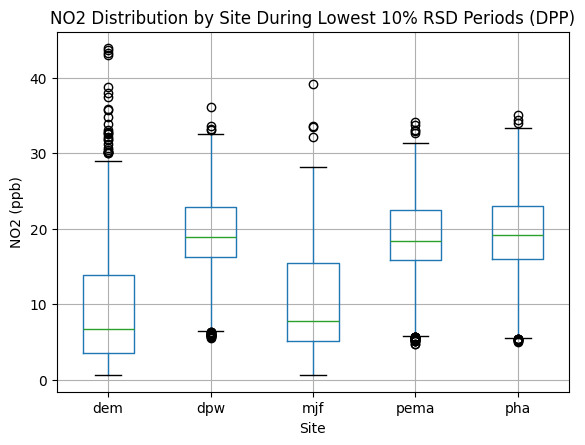

In [49]:
low_rsd_melted = no2_low_rsd_dpp.melt(id_vars="datetime_utc", value_vars=["dem", "dpw", "mjf", "pema", "pha"], var_name="site", value_name="no2")
low_rsd_melted = low_rsd_melted.dropna(subset=["no2"])

plt.figure(figsize=(8, 6))
low_rsd_melted.boxplot(column="no2", by="site")
plt.title("NO2 Distribution by Site During Lowest 10% RSD Periods (DPP)")
plt.suptitle("")
plt.xlabel("Site")
plt.ylabel("NO2 (ppb)")
plt.show()

In [50]:
no2_mjf_dem = no2.copy()

no2_mjf_dem = no2_mjf_dem.dropna(subset=["mjf", "dem"])

row_mean = no2_mjf_dem[["mjf", "dem"]].mean(axis=1)
row_std = no2_mjf_dem[["mjf", "dem"]].std(axis=1, ddof=1)

no2_mjf_dem["rsd_mjf_dem"] = 100 * row_std / row_mean

In [51]:
no2_mjf_dem["rsd_mjf_dem"].describe()

count    5183.000000
mean       39.846763
std        29.220951
min         0.000000
25%        15.635455
50%        32.373563
75%        61.696280
max       134.350288
Name: rsd_mjf_dem, dtype: float64

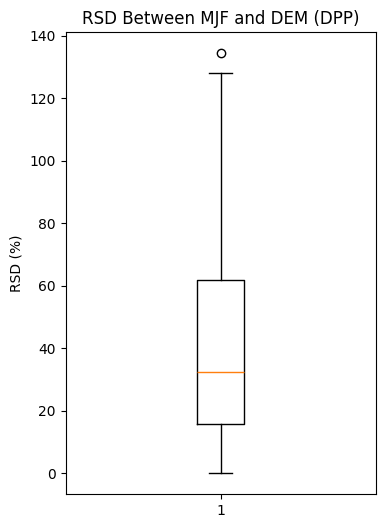

In [52]:
plt.figure(figsize=(4, 6))
plt.boxplot(no2_mjf_dem["rsd_mjf_dem"].dropna())
plt.ylabel("RSD (%)")
plt.title("RSD Between MJF and DEM (DPP)")
plt.show()

### Now we include MJF in our identification of low RSD time periods

In [53]:
no2_rsd = no2.dropna(subset=["dpw", "pema", "pha", "mjf"]).copy()

cols = ["dpw", "pema", "pha", "mjf"]

#calculate mean and standard deviation
row_mean = no2_rsd[cols].mean(axis=1)
row_std = no2_rsd[cols].std(axis=1, ddof=1)

no2_rsd["rsd"] = 100 * row_std / row_mean

no2_rsd.head()

,datetime_utc,dem,dpw,mjf,pema,pha,rsd
1,2025-10-09 23:00:00,7.8,26.0,10.4,6.7,33.4,66.245670
2,2025-10-10 00:00:00,16.5,28.0,17.3,6.7,28.0,51.004902
3,2025-10-10 01:00:00,15.8,30.7,15.9,6.9,24.8,53.190152
4,2025-10-10 02:00:00,15.7,24.5,13.4,6.9,21.5,48.107774
5,2025-10-10 03:00:00,15.3,23.6,11.4,7.0,18.6,48.771985


In [54]:
no2_rsd["network_mean"] = no2_rsd[["dpw", "pema", "pha", "mjf"]].mean(axis=1)

threshold = 14.35

low_bin = no2_rsd[no2_rsd["network_mean"] < threshold].copy()
high_bin = no2_rsd[no2_rsd["network_mean"] >= threshold].copy()

low_cutoff = low_bin["rsd"].quantile(0.10)
high_cutoff = high_bin["rsd"].quantile(0.10)

low_selected = low_bin[low_bin["rsd"] <= low_cutoff]
high_selected = high_bin[high_bin["rsd"] <= high_cutoff]

no2_low_rsd_dppm = pd.concat([low_selected, high_selected])

In [55]:
no2_low_rsd_dppm.to_csv("low RSD data/no2_low_rsd_dppm.csv", index=False)
no2_low_rsd_dppm.head(30)

,datetime_utc,dem,dpw,mjf,pema,pha,rsd,network_mean
450,2025-10-28 16:00:00,1.3,7.1,3.8,5.0,6.3,26.172683,5.550
451,2025-10-28 17:00:00,1.3,8.3,4.3,5.4,6.7,27.904891,6.175
520,2025-10-31 14:00:00,NaN,5.9,3.1,4.5,4.6,25.285927,4.525
521,2025-10-31 15:00:00,NaN,6.2,3.6,4.8,5.3,21.796151,4.975
522,2025-10-31 16:00:00,NaN,7.5,3.8,5.1,6.2,27.891320,5.650
523,2025-10-31 17:00:00,NaN,8.0,4.0,5.8,7.3,28.250355,6.275
524,2025-10-31 18:00:00,NaN,8.1,4.1,5.8,7.8,28.991281,6.450
525,2025-10-31 19:00:00,NaN,8.4,4.3,5.7,6.4,27.529822,6.200
571,2025-11-02 17:00:00,1.1,9.8,5.2,6.4,7.2,27.251800,7.150
618,2025-11-04 16:00:00,1.0,10.0,5.6,7.3,7.6,23.760880,7.625


<Figure size 800x600 with 0 Axes>

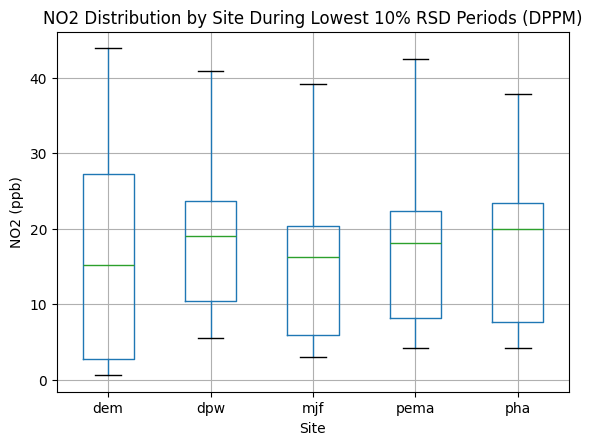

In [56]:
low_rsd_melted = no2_low_rsd_dppm.melt(id_vars="datetime_utc", value_vars=["dem", "dpw", "mjf", "pema", "pha"], var_name="site", value_name="no2")
low_rsd_melted = low_rsd_melted.dropna(subset=["no2"])

plt.figure(figsize=(8, 6))
low_rsd_melted.boxplot(column="no2", by="site")
plt.title("NO2 Distribution by Site During Lowest 10% RSD Periods (DPPM)")
plt.suptitle("")
plt.xlabel("Site")
plt.ylabel("NO2 (ppb)")
plt.show()